# Taller SBC - Consulta del dataset médico (Heart Disease)

Este notebook carga y explora el dataset **Heart Disease** de UCI, útil para el taller de **redes bayesianas**.

## Objetivos
- Cargar el dataset desde UCI.
- Revisar sus dimensiones y tipos de variables.
- Tener una base lista para modelar relaciones entre factores de riesgo, síntomas, pruebas y diagnóstico.


## Descripción de las dimensiones

A continuación se resumen las **variables principales** del dataset **Framingham Heart Study**, orientado a estimar el riesgo de enfermedad coronaria a 10 años:

| Dimensión | Descripción |
|---|---|
| `male` | Sexo biológico codificado (1 = masculino, 0 = femenino). |
| `age` | Edad del paciente, en años. |
| `education` | Nivel educativo codificado por categorías ordinales. |
| `currentSmoker` | Indica si la persona fuma actualmente (1 = sí, 0 = no). |
| `cigsPerDay` | Cantidad promedio de cigarrillos consumidos por día. |
| `BPMeds` | Indica si la persona usa medicación para presión arterial (1 = sí, 0 = no). |
| `prevalentStroke` | Indica si la persona ha tenido un accidente cerebrovascular previo (1 = sí, 0 = no). |
| `prevalentHyp` | Indica si la persona presenta hipertensión prevalente (1 = sí, 0 = no). |
| `diabetes` | Indica si la persona tiene diabetes (1 = sí, 0 = no). |
| `totChol` | Colesterol total, usualmente expresado en mg/dl. |
| `sysBP` | Presión arterial sistólica. |
| `diaBP` | Presión arterial diastólica. |
| `BMI` | Índice de masa corporal. |
| `heartRate` | Frecuencia cardiaca. |
| `glucose` | Nivel de glucosa en sangre. |
| `TenYearCHD` | Variable objetivo: presencia o ausencia de enfermedad coronaria a 10 años (1 = sí, 0 = no). |

### Lectura conceptual para el taller
Estas dimensiones permiten estructurar una red bayesiana con capas como:
- **factores base**: `age`, `male`, `education`
- **hábitos y exposición**: `currentSmoker`, `cigsPerDay`
- **antecedentes clínicos**: `prevalentStroke`, `prevalentHyp`, `diabetes`, `BPMeds`
- **mediciones fisiológicas**: `totChol`, `sysBP`, `diaBP`, `BMI`, `heartRate`, `glucose`
- **resultado objetivo**: `TenYearCHD`

In [10]:
import pandas as pd

url = "https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/5d689a024551e672313f7fd7eb1bee8d_framingham.csv"

df_medico = pd.read_csv(url)

X = df_medico.drop(columns=["TenYearCHD"])
y = df_medico[["TenYearCHD"]]

df_medico = pd.concat([X, y], axis=1)

print("Forma del dataset:", df_medico.shape)
df_medico.head()

Forma del dataset: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [11]:
print("Columnas:")
print(df_medico.columns.tolist())

Columnas:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [12]:
print("Información general:")
df_medico.info()

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [13]:
print("Valores faltantes por columna:")
df_medico.isna().sum().sort_values(ascending=False)

Valores faltantes por columna:


glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
male                 0
prevalentHyp         0
prevalentStroke      0
age                  0
currentSmoker        0
diaBP                0
sysBP                0
diabetes             0
TenYearCHD           0
dtype: int64

In [14]:
import pandas as pd
import numpy as np

def discretize_dataframe(df):

    df = df.copy()

    # --- totChol ---
    df["totChol_cat"] = np.where(df["totChol"] < 200, "<200", ">=200")

    # --- sysBP ---
    df["sysBP_cat"] = np.where(df["sysBP"] < 120, "<120", ">=120")

    # --- diaBP ---
    df["diaBP_cat"] = np.where(df["diaBP"] < 80, "<80", ">=80")

    # --- BMI ---
    df["BMI_cat"] = pd.cut(
        df["BMI"],
        bins=[-np.inf, 18.5, 24.9, np.inf],
        labels=["<18.5", "18.5-24.9", ">=25"]
    )

    # --- heartRate ---
    df["heartRate_cat"] = pd.cut(
        df["heartRate"],
        bins=[-np.inf, 60, 100, np.inf],
        labels=["<60", "60-100", ">100"]
    )

    # --- glucose ---
    df["glucose_cat"] = pd.cut(
        df["glucose"],
        bins=[-np.inf, 100, 126, np.inf],
        labels=["<=100", "100-126", ">=126"]
    )

    # --- age ---
    df["age_cat"] = pd.cut(
        df["age"],
        bins=[-np.inf, 18, 45, 65, np.inf],
        labels=["<18", "18-45", "45-65", ">=65"]
    )

    # Drop original continuous columns
    df = df.drop(columns=["totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose", "age"])

    return df

df_medico = discretize_dataframe(df_medico)
print("Variables discretizadas añadidas:")

print([c for c in df_medico.columns if c.endswith("_cat")])
df_medico.head()

Variables discretizadas añadidas:
['totChol_cat', 'sysBP_cat', 'diaBP_cat', 'BMI_cat', 'heartRate_cat', 'glucose_cat', 'age_cat']


,male,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,TenYearCHD,totChol_cat,sysBP_cat,diaBP_cat,BMI_cat,heartRate_cat,glucose_cat,age_cat
0,1,4.0,0,0.0,0.0,0,0,0,0,<200,<120,<80,>=25,60-100,<=100,18-45
1,0,2.0,0,0.0,0.0,0,0,0,0,>=200,>=120,>=80,>=25,60-100,<=100,45-65
2,1,1.0,1,20.0,0.0,0,0,0,0,>=200,>=120,>=80,>=25,60-100,<=100,45-65
3,0,3.0,1,30.0,0.0,0,1,0,1,>=200,>=120,>=80,>=25,60-100,100-126,45-65
4,0,3.0,1,23.0,0.0,0,0,0,0,>=200,>=120,>=80,18.5-24.9,60-100,<=100,45-65


## Red Bayesiana con pgmpy

Entrenamos una red bayesiana **desde cero** en tres pasos:

1. **Aprendizaje de estructura** (`HillClimbSearch` + `BicScore`): el algoritmo busca el grafo acíclico dirigido (DAG) que mejor explica los datos.
2. **Aprendizaje de parámetros** (`BayesianEstimator`): estima las tablas de probabilidad condicional (CPD) con prior de Dirichlet.
3. **Inferencia** (`VariableElimination`): consulta la probabilidad de `TenYearCHD` dado un conjunto de evidencias.


In [15]:
import pandas as pd
import numpy as np

# --- 1. Preparación de datos para pgmpy ---
# pgmpy requiere datos sin NaN y con valores discretos (enteros o strings)

df_pgmpy = df_medico.copy()

# Convertir columnas categóricas (pd.Categorical) a string
cat_cols = [c for c in df_pgmpy.columns if str(df_pgmpy[c].dtype) == "category"]
for col in cat_cols:
    df_pgmpy[col] = df_pgmpy[col].astype(str)

# Convertir columnas continuas restantes a entero
int_cols = ["male", "education", "currentSmoker", "cigsPerDay", "BPMeds",
            "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD"]
for col in int_cols:
    if col in df_pgmpy.columns:
        df_pgmpy[col] = df_pgmpy[col].astype("Int64").astype(str)

# Eliminar filas con NaN (imprescindible para pgmpy)
df_pgmpy = df_pgmpy.dropna()

print(f"Filas para entrenamiento: {len(df_pgmpy)}")
print("Columnas:", df_pgmpy.columns.tolist())
df_pgmpy.head()


Filas para entrenamiento: 3667
Columnas: ['male', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD', 'totChol_cat', 'sysBP_cat', 'diaBP_cat', 'BMI_cat', 'heartRate_cat', 'glucose_cat', 'age_cat']


,male,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,TenYearCHD,totChol_cat,sysBP_cat,diaBP_cat,BMI_cat,heartRate_cat,glucose_cat,age_cat
0,1,4,0,0,0,0,0,0,0,<200,<120,<80,>=25,60-100,<=100,18-45
1,0,2,0,0,0,0,0,0,0,>=200,>=120,>=80,>=25,60-100,<=100,45-65
2,1,1,1,20,0,0,0,0,0,>=200,>=120,>=80,>=25,60-100,<=100,45-65
3,0,3,1,30,0,0,1,0,1,>=200,>=120,>=80,>=25,60-100,100-126,45-65
4,0,3,1,23,0,0,0,0,0,>=200,>=120,>=80,18.5-24.9,60-100,<=100,45-65


In [16]:
from pgmpy.estimators import HillClimbSearch, BIC

BicScore = BIC

# --- 2. Aprendizaje de estructura ---
# HillClimbSearch recorre el espacio de DAGs maximizando el BIC Score
scoring_method = BicScore(df_pgmpy)
hc = HillClimbSearch(df_pgmpy)

print("Buscando la mejor estructura (puede tardar unos segundos)...")
best_model = hc.estimate(
    scoring_method=scoring_method,
    max_indegree=3,   # máximo de padres por nodo (controla complejidad)
    max_iter=500,
    show_progress=True
)

print(f"\nNodos: {best_model.nodes()}")
print(f"\nAristas aprendidas ({len(best_model.edges())}):")
for edge in sorted(best_model.edges()):
    print(f"  {edge[0]}  →  {edge[1]}")


Buscando la mejor estructura (puede tardar unos segundos)...

C:\Users\Vargas\AppData\Local\Temp\ipykernel_11392\2847439995.py:8: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(df_pgmpy)


  5%|▍         | 23/500 [00:04<01:31,  5.23it/s]


Nodos: ['male', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD', 'totChol_cat', 'sysBP_cat', 'diaBP_cat', 'BMI_cat', 'heartRate_cat', 'glucose_cat', 'age_cat']

Aristas aprendidas (23):
  BPMeds  →  prevalentStroke
  TenYearCHD  →  glucose_cat
  age_cat  →  TenYearCHD
  age_cat  →  currentSmoker
  age_cat  →  education
  age_cat  →  totChol_cat
  cigsPerDay  →  male
  currentSmoker  →  BMI_cat
  currentSmoker  →  cigsPerDay
  diaBP_cat  →  BMI_cat
  diaBP_cat  →  currentSmoker
  diaBP_cat  →  prevalentHyp
  diaBP_cat  →  sysBP_cat
  glucose_cat  →  diabetes
  male  →  BMI_cat
  male  →  education
  male  →  totChol_cat
  prevalentHyp  →  BPMeds
  prevalentHyp  →  TenYearCHD
  prevalentHyp  →  age_cat
  prevalentHyp  →  heartRate_cat
  sysBP_cat  →  age_cat
  sysBP_cat  →  prevalentHyp


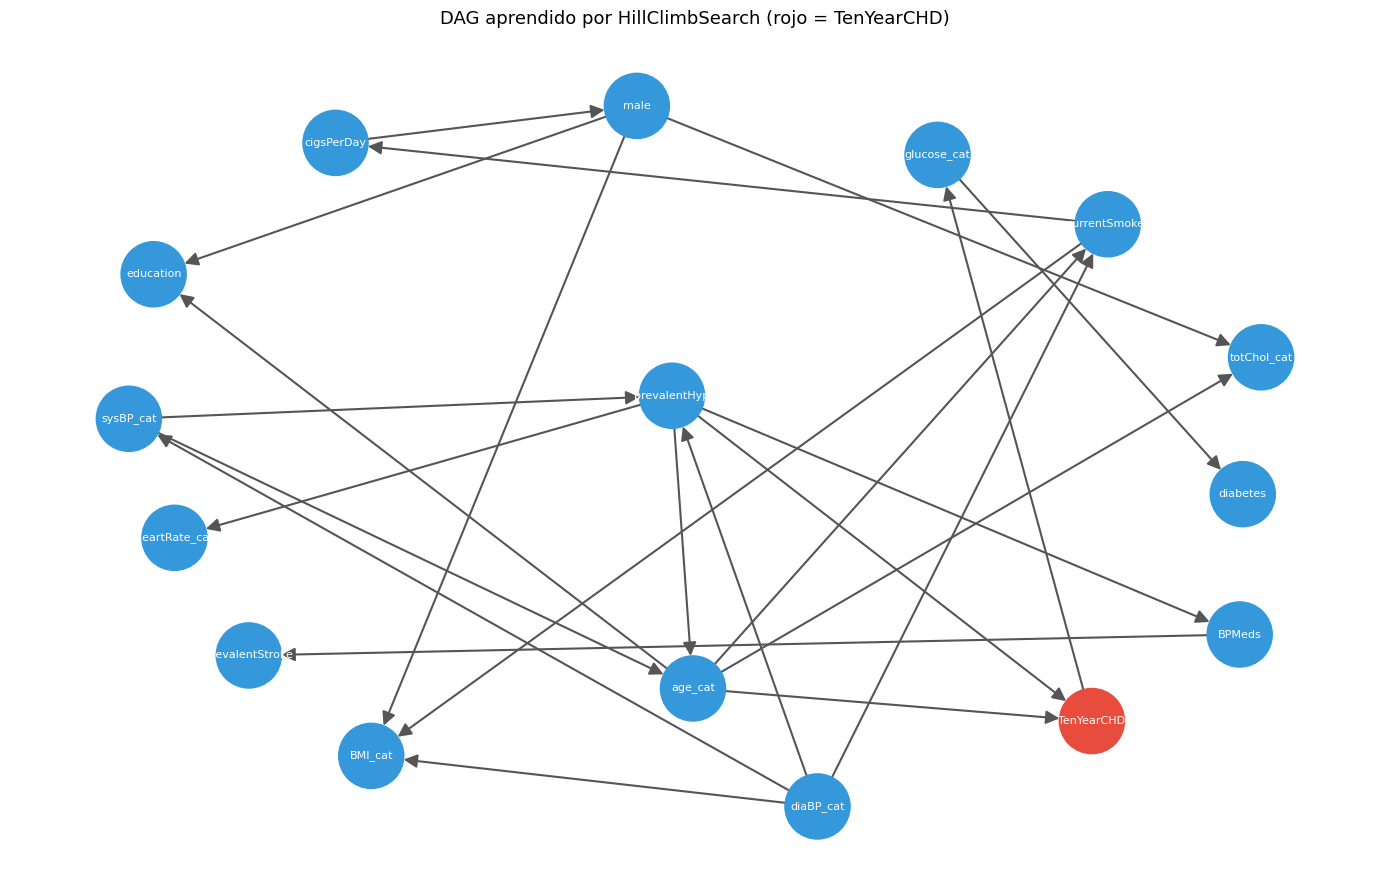

In [17]:
import matplotlib.pyplot as plt
import networkx as nx

# --- 3. Visualización del DAG aprendido ---
G = nx.DiGraph(best_model.edges())

# Colorear el nodo objetivo de forma distinta
node_colors = ["#e74c3c" if n == "TenYearCHD" else "#3498db" for n in G.nodes()]

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw_networkx(
    G, pos,
    node_color=node_colors,
    node_size=2200,
    font_size=8,
    font_color="white",
    edge_color="#555555",
    arrows=True,
    arrowsize=20,
    width=1.5,
)
plt.title("DAG aprendido por HillClimbSearch (rojo = TenYearCHD)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()


In [18]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import BayesianEstimator

# --- 4. Aprendizaje de parámetros ---
# Construimos la BayesianNetwork con la estructura aprendida
bn_model = BayesianNetwork(best_model.edges())

# BayesianEstimator usa prior de Dirichlet (equivalent_sample_size suaviza estimaciones)
bn_model.fit(
    df_pgmpy,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10,
)

print("Modelo entrenado correctamente.")
print(f"CPDs estimadas: {len(bn_model.cpds)}\n")

# Mostrar CPD del nodo objetivo
cpd_chd = bn_model.get_cpds("TenYearCHD")
print("CPD de TenYearCHD:")
print(cpd_chd)


ImportError: `BayesianNetwork` is deprecated. Please use `DiscreteBayesianNetwork` instead.

In [ ]:
from pgmpy.inference import VariableElimination

# --- 5. Inferencia con Variable Elimination ---
infer = VariableElimination(bn_model)

# ---- Consulta 1: paciente de alto riesgo ----
evidence_alto_riesgo = {}
available = set(bn_model.nodes()) - {"TenYearCHD"}

candidates_alto = {
    "male": "1",
    "age_cat": "45-65",
    "currentSmoker": "1",
    "prevalentHyp": "1",
    "diabetes": "1",
    "sysBP_cat": ">=120",
    "glucose_cat": ">=126",
}
evidence_alto_riesgo = {k: v for k, v in candidates_alto.items() if k in available}

q1 = infer.query(variables=["TenYearCHD"], evidence=evidence_alto_riesgo, show_progress=False)
print("=== Consulta 1: Paciente de ALTO riesgo ===")
print(f"Evidencia: {evidence_alto_riesgo}")
print(q1)

# ---- Consulta 2: paciente de bajo riesgo ----
candidates_bajo = {
    "male": "0",
    "age_cat": "18-45",
    "currentSmoker": "0",
    "prevalentHyp": "0",
    "diabetes": "0",
    "sysBP_cat": "<120",
    "glucose_cat": "<=100",
}
evidence_bajo_riesgo = {k: v for k, v in candidates_bajo.items() if k in available}

q2 = infer.query(variables=["TenYearCHD"], evidence=evidence_bajo_riesgo, show_progress=False)
print("\n=== Consulta 2: Paciente de BAJO riesgo ===")
print(f"Evidencia: {evidence_bajo_riesgo}")
print(q2)
